# IMDB Reviews — Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

pd.set_option('display.max_colwidth', 200)

## 1) Load data

In [ ]:
# Run this if you haven't downloaded the dataset yet

import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

DATA_Path = Path(path) / "IMDB Dataset.csv"

df = pd.read_csv(DATA_Path)
df.head()

In [ ]:
# Run this if you have already downloaded the dataset

DATA_PATH = Path('../data/IMDB Dataset.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",positive


## 2) Basic info & null checks

In [5]:
display(df.info())
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


None

review       0
sentiment    0
dtype: int64

## 3) Label distribution

In [6]:
label_counts = df['sentiment'].value_counts().sort_index()
label_counts

sentiment
negative    25000
positive    25000
Name: count, dtype: int64

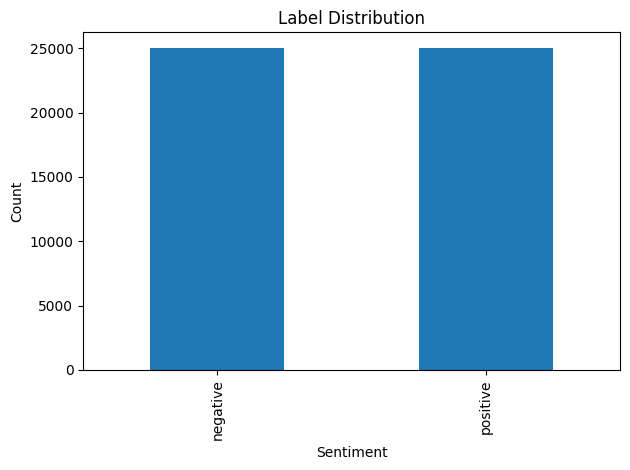

In [7]:
# Bar chart
plt.figure()
label_counts.plot(kind='bar')
plt.title('Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Document lengths

In [8]:
from nltk.tokenize import ToktokTokenizer
tokenizer = ToktokTokenizer()

def simple_tokenize(text):
    tokens = tokenizer.tokenize(str(text).lower())
    return tokens

df['char_len'] = df['review'].astype(str).str.len()
df['tok_len']  = df['review'].astype(str).apply(lambda s: len(simple_tokenize(s)))
df[['char_len','tok_len']].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.95])

,char_len,tok_len
count,50000.000000,50000.000000
mean,1309.431020,266.162700
std,989.728014,198.262731
min,32.000000,8.000000
10%,501.000000,103.000000
25%,699.000000,144.000000
50%,970.000000,199.000000
75%,1590.250000,323.000000
90%,2581.000000,522.000000
95%,3391.000000,683.000000


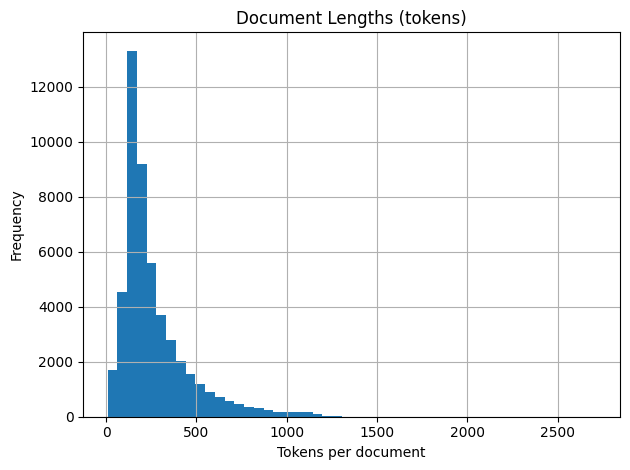

In [9]:
# Histogram: token lengths
plt.figure()
df['tok_len'].hist(bins=50)
plt.title('Document Lengths (tokens)')
plt.xlabel('Tokens per document')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

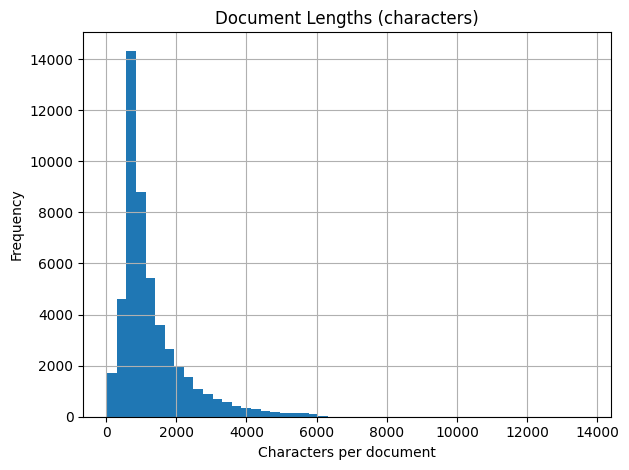

In [15]:
# Histogram: character lengths
plt.figure()
df['char_len'].hist(bins=50)
plt.title('Document Lengths (characters)')
plt.xlabel('Characters per document')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5) Vocabulary richness

**Type–Token Ratio (TTR)**: unique tokens / total tokens

In [10]:
tokens_series = df['review'].astype(str).apply(simple_tokenize)
all_tokens = [t for toks in tokens_series for t in toks]
N = len(all_tokens)
types = set(all_tokens)
V = len(types)
freq = Counter(all_tokens)
ttr = V / N if N else 0
print({'N_tokens': N, 'V_types': V, 'TTR': round(ttr,4)})

{'N_tokens': 13308135, 'V_types': 198172, 'TTR': 0.0149}


In [11]:
pd.DataFrame(freq.most_common(30), columns=['term','count'])

,term,count
0,the,650531
1,",",543696
2,and,321582
3,a,319481
4,of,287795
5,to,265845
6,',263760
7,is,209082
8,/,202499
9,in,182398


## 6) Length vs label

In [22]:
df.groupby('sentiment')[['tok_len','char_len']].mean().round(2)

,tok_len,char_len
sentiment,,
negative,265.12,1294.06
positive,267.21,1324.80


## 7) Compact EDA summary

In [26]:
summary = {
    'n_rows': len(df),
    'n_positive': int((df['sentiment']=='positive').sum()),
    'n_negative': int((df['sentiment']=='negative').sum()),
    'avg_tok_len': float(df['tok_len'].mean()),
    'avg_char_len': float(df['char_len'].mean()),
    'TTR': round(float(ttr), 4)
}
summary

{'n_rows': 50000,
 'n_positive': 25000,
 'n_negative': 25000,
 'avg_tok_len': 266.1627,
 'avg_char_len': 1309.43102,
 'TTR': 0.0149}